In [3]:
import pandas as pd
import numpy as np
import requests, zipfile, io
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.rcParams.update({font-size: 14})

NameError: name 'matplotlib' is not defined

1. Загрузим данные

In [4]:
DATASET_PATH = '../data/raw/housing.csv'

In [5]:
df = pd.read_csv(DATASET_PATH, sep=',')

Первичный осмотр датасета

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4


Размер датасета

In [7]:
df.shape

(20640, 11)

1. Распределение целевой переменной

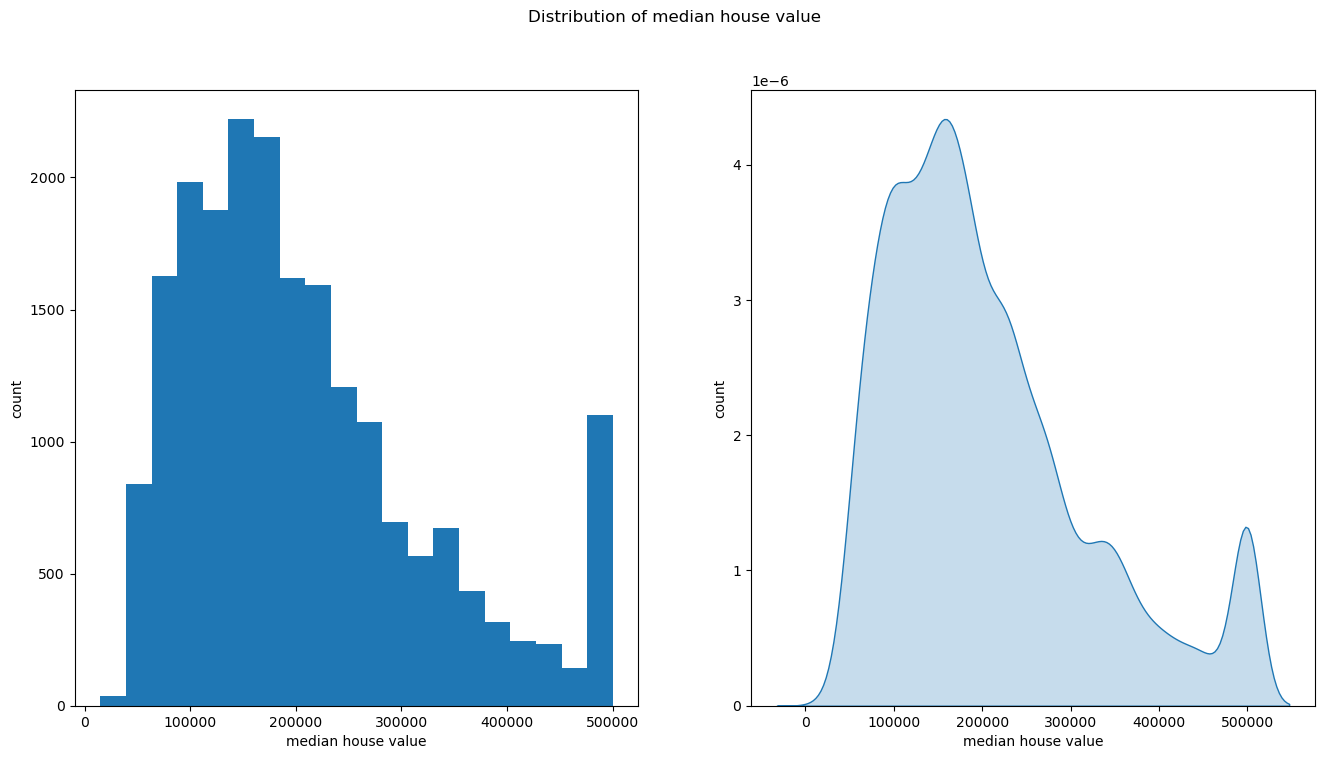

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].hist(df['median_house_value'], bins=20)
ax[0].set_ylabel('count')
ax[0].set_xlabel('median house value')

sns.kdeplot(data=df, x='median_house_value', fill=True, legend=False, ax=ax[1])
ax[1].set_ylabel('count')
ax[1].set_xlabel('median house value')

fig.suptitle('Distribution of median house value')
# Сохраним чарт
plt.savefig('../charts/Target before.png', dpi=150, bbox_inches='tight')
plt.show()

Дома стоимостью выше 500000, вероятно, выбросы

Меры центральной тенденции

In [13]:
target_mean = round(df['median_house_value'].mean(), 2)
target_median = df['median_house_value'].median()
#Мод может быть несколько, берём одну
target_mode = df['median_house_value'].mode()[0]

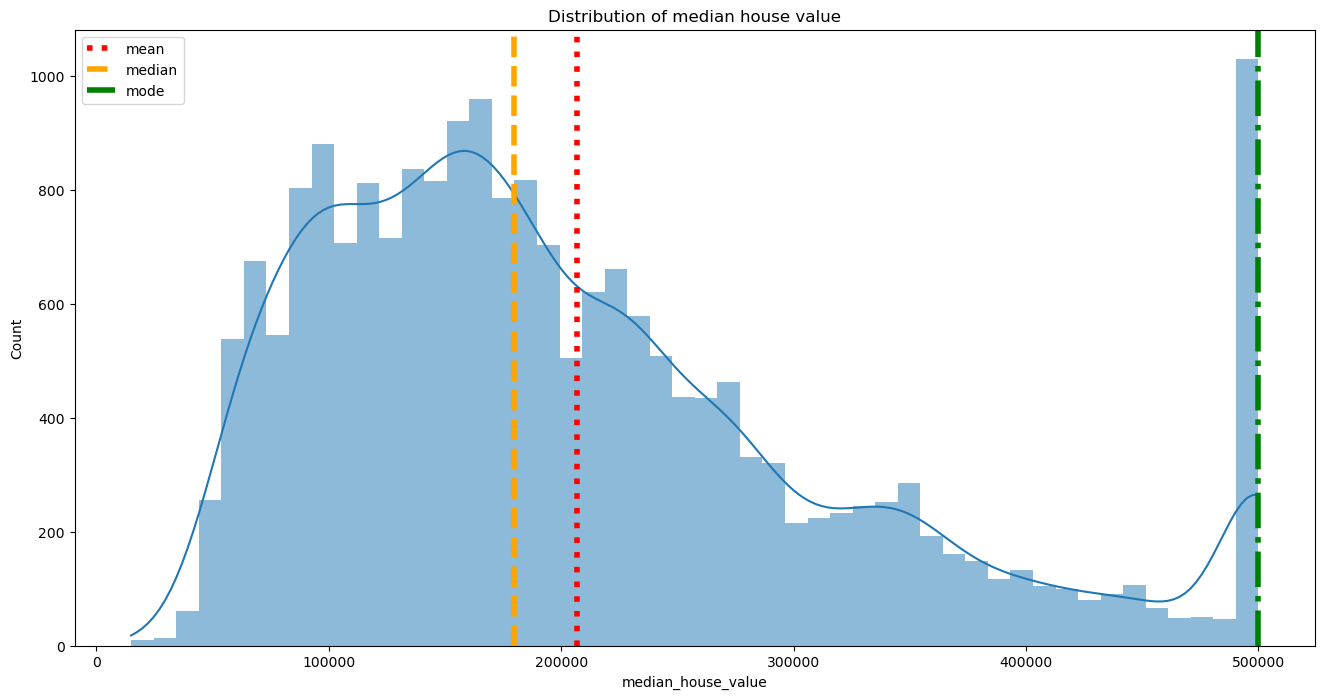

In [14]:
plt.figure(figsize=(16, 8))

sns.histplot(data=df, x='median_house_value', bins=50, kde=True, edgecolor=None)

plt.axvline(target_mean, color='red', linestyle=':', linewidth=4, label='mean')
plt.axvline(target_median, color='orange', linestyle='--', linewidth=4, label='median')
plt.axvline(target_mode, color='green', linestyle='-.', linewidth=4, label='mode')

plt.title('Distribution of median house value')
plt.legend()
plt.savefig('../charts/Distribution of median_house_value before.png', dpi=150, bbox_inches='tight')
plt.show()

median_house_value - вещественная величина. Мода подходит для категориального признака и не подходит для вещественного. Сделаем из вещественного признака категориальный

In [15]:
target_bins = df['median_house_value'] // 10000 * 10000
#0 -- 10000 - первая категория
#10001 -- 20000 - вторая
# ...
target_adjusted_mode = target_bins.mode()[0]
target_adjusted_mode

np.float64(160000.0)

In [16]:
df['median_house_value'].value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
359200.0      1
54900.0       1
377600.0      1
81200.0       1
47000.0       1
Name: count, Length: 3842, dtype: int64

In [17]:
target_bins.value_counts().head()

median_house_value
160000.0    1005
500000.0     992
150000.0     970
90000.0      920
180000.0     853
Name: count, dtype: int64

Всего категорий

In [18]:
len(np.unique(target_bins))

50

In [19]:
np.unique(target_bins)

array([ 10000.,  20000.,  30000.,  40000.,  50000.,  60000.,  70000.,
        80000.,  90000., 100000., 110000., 120000., 130000., 140000.,
       150000., 160000., 170000., 180000., 190000., 200000., 210000.,
       220000., 230000., 240000., 250000., 260000., 270000., 280000.,
       290000., 300000., 310000., 320000., 330000., 340000., 350000.,
       360000., 370000., 380000., 390000., 400000., 410000., 420000.,
       430000., 440000., 450000., 460000., 470000., 480000., 490000.,
       500000.])

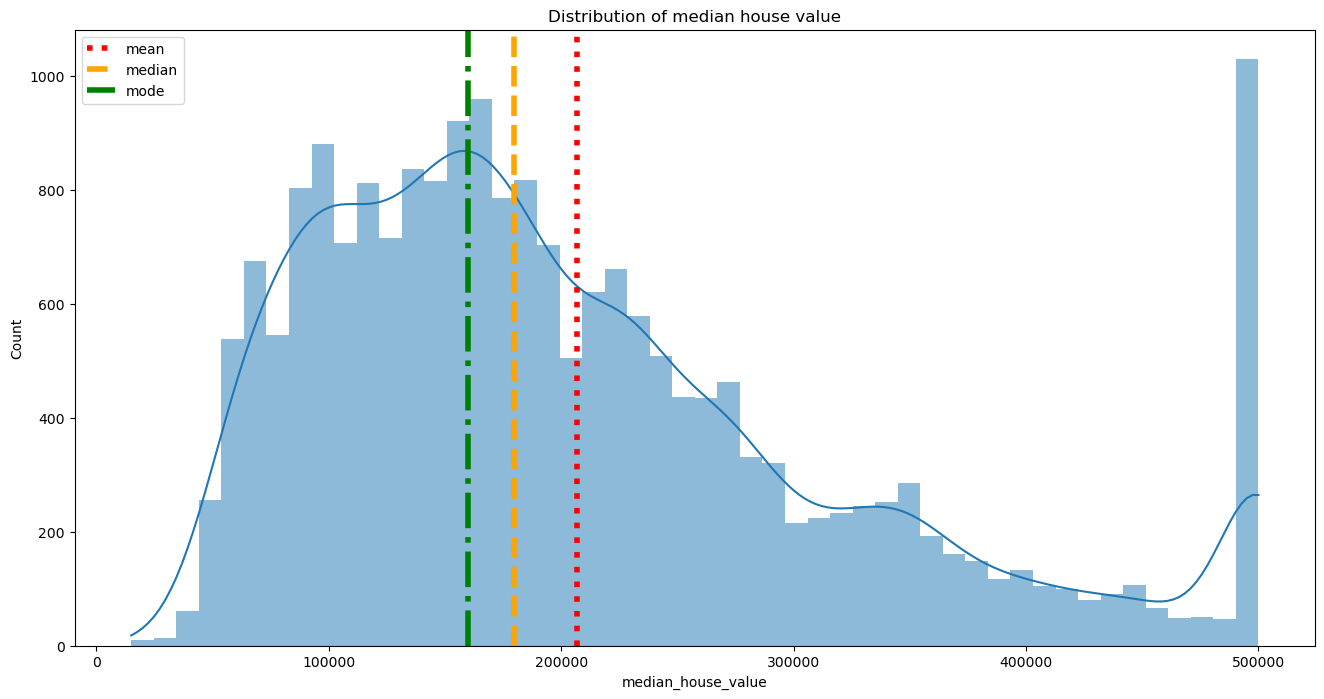

In [20]:
plt.figure(figsize=(16,8))

sns.histplot(data=df, x='median_house_value', bins=50, kde=True, edgecolor=None)

plt.axvline(target_mean, color='red', linestyle=':', linewidth=4, label='mean')
plt.axvline(target_median, color='orange', linestyle='--', linewidth=4, label='median')
plt.axvline(target_adjusted_mode, color='green', linestyle='-.', linewidth=4, label='mode')

plt.title('Distribution of median house value')
plt.legend()

plt.show()


In [21]:
df['median_house_value'].value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
359200.0      1
54900.0       1
377600.0      1
81200.0       1
47000.0       1
Name: count, Length: 3842, dtype: int64

Выкинем странные выбросы из выборки

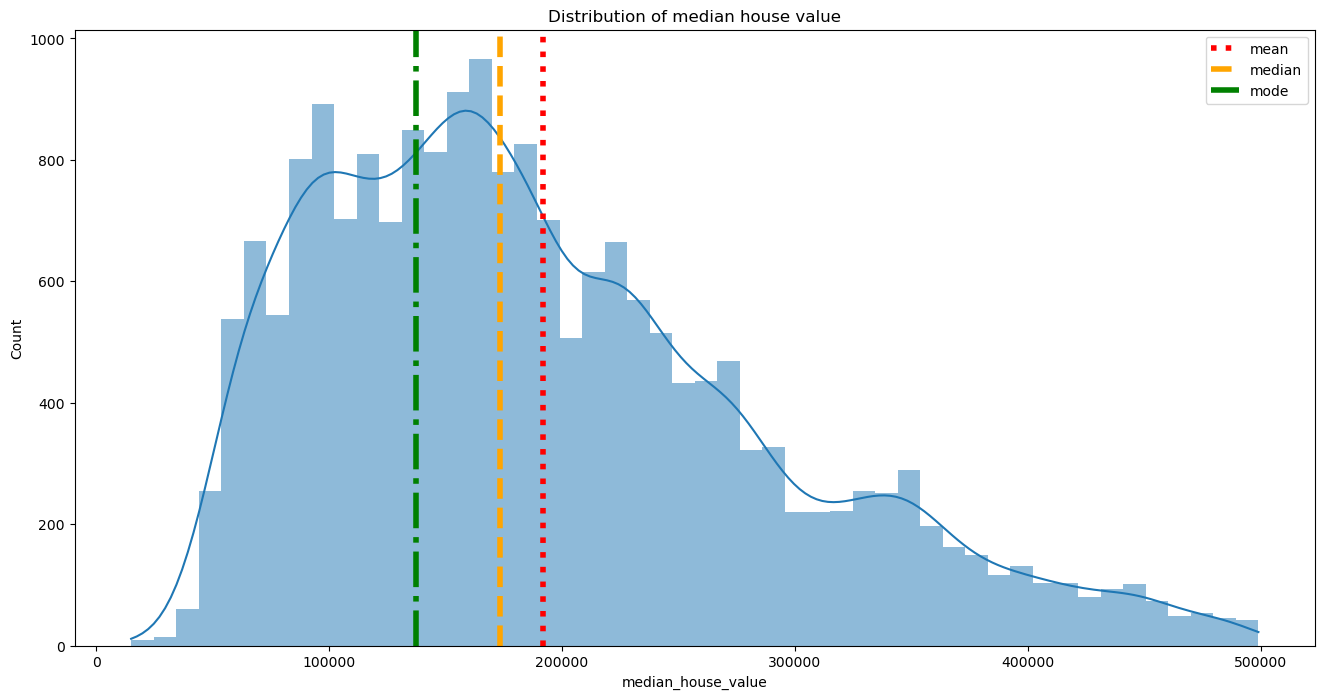

In [22]:
dfc = df[df['median_house_value'] < 500000] #Оставляем дома стоимостью менее 500000

target_mean = round(dfc['median_house_value'].mean(), 2)
target_median = dfc['median_house_value'].median()
target_mode = dfc['median_house_value'].mode()[0]

plt.figure(figsize=(16,8))

sns.histplot(data=dfc, x='median_house_value', bins=50, kde=True, edgecolor=None)

plt.axvline(target_mean, color='red', linestyle=':', linewidth=4, label='mean')
plt.axvline(target_median, color='orange', linestyle='--', linewidth=4, label='median')
plt.axvline(target_mode, color='green', linestyle='-.', linewidth=4, label='mode')

plt.title('Distribution of median house value')
plt.legend()
plt.savefig('../charts/Distribution of median_house_value after.png', dpi=150, bbox_inches='tight')
plt.show()

Сохраним очищенный дата сет

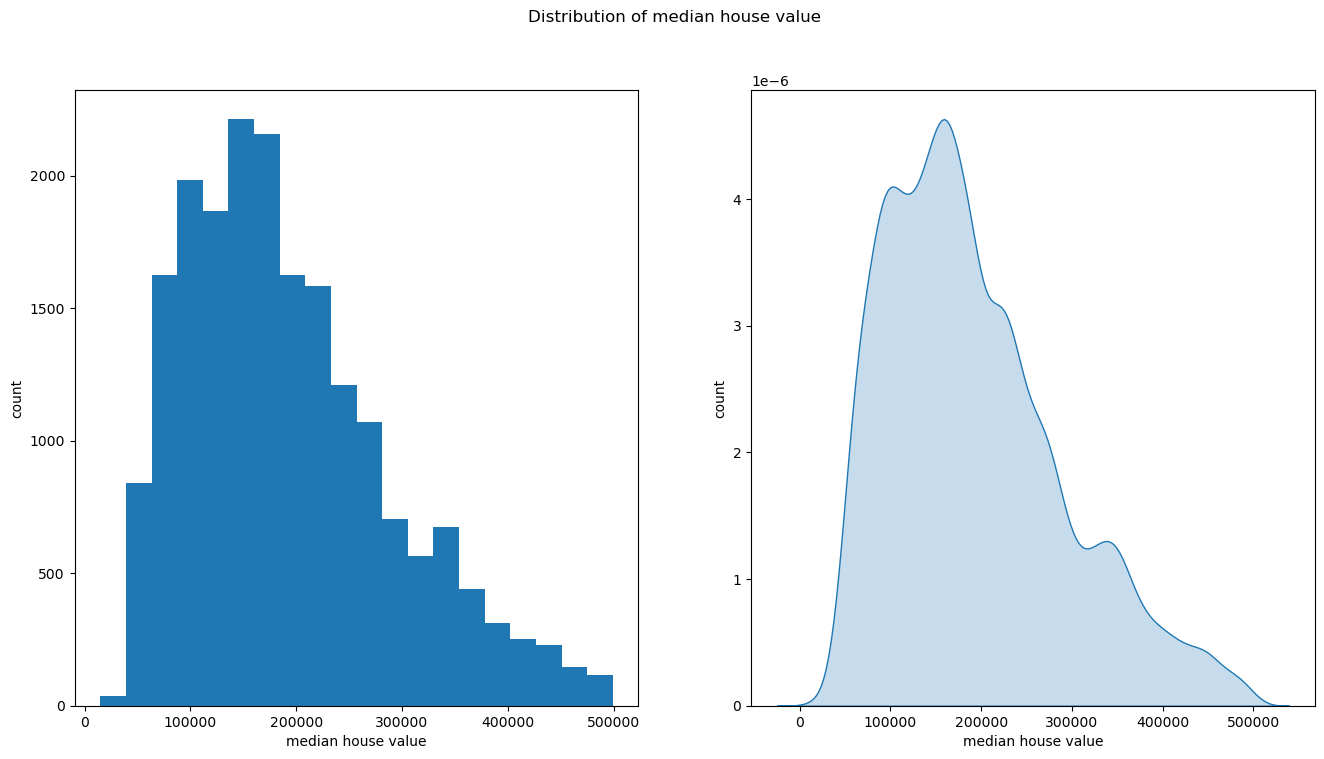

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].hist(dfc['median_house_value'], bins=20)
ax[0].set_ylabel('count')
ax[0].set_xlabel('median house value')

sns.kdeplot(data=dfc, x='median_house_value', fill=True, legend=False, ax=ax[1])
ax[1].set_ylabel('count')
ax[1].set_xlabel('median house value')

fig.suptitle('Distribution of median house value')

plt.savefig('../charts/target_after.png', dpi=150, bbox_inches='tight')
dfc.to_csv('../data/processed/housing_clean.csv', index=False)

2. Анализ признаков

2.1 Пропуски

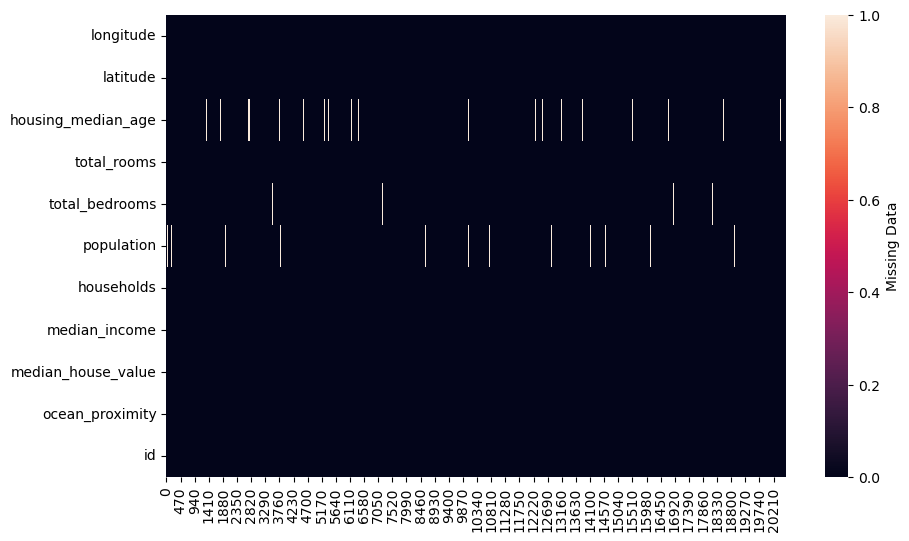

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna().transpose(),
           cbar_kws={'label': 'Missing Data'});
plt.savefig('../charts/Heatmap.png', dpi=150, bbox_inches='tight')


2.2 Количественные признаки

Уберём целевое значение

In [25]:
df_num_features = df.select_dtypes(include=['float64', 'float32', 'float16'])
df_num_features.drop('median_house_value', axis=1, inplace=True)

In [26]:
df_num_features.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462


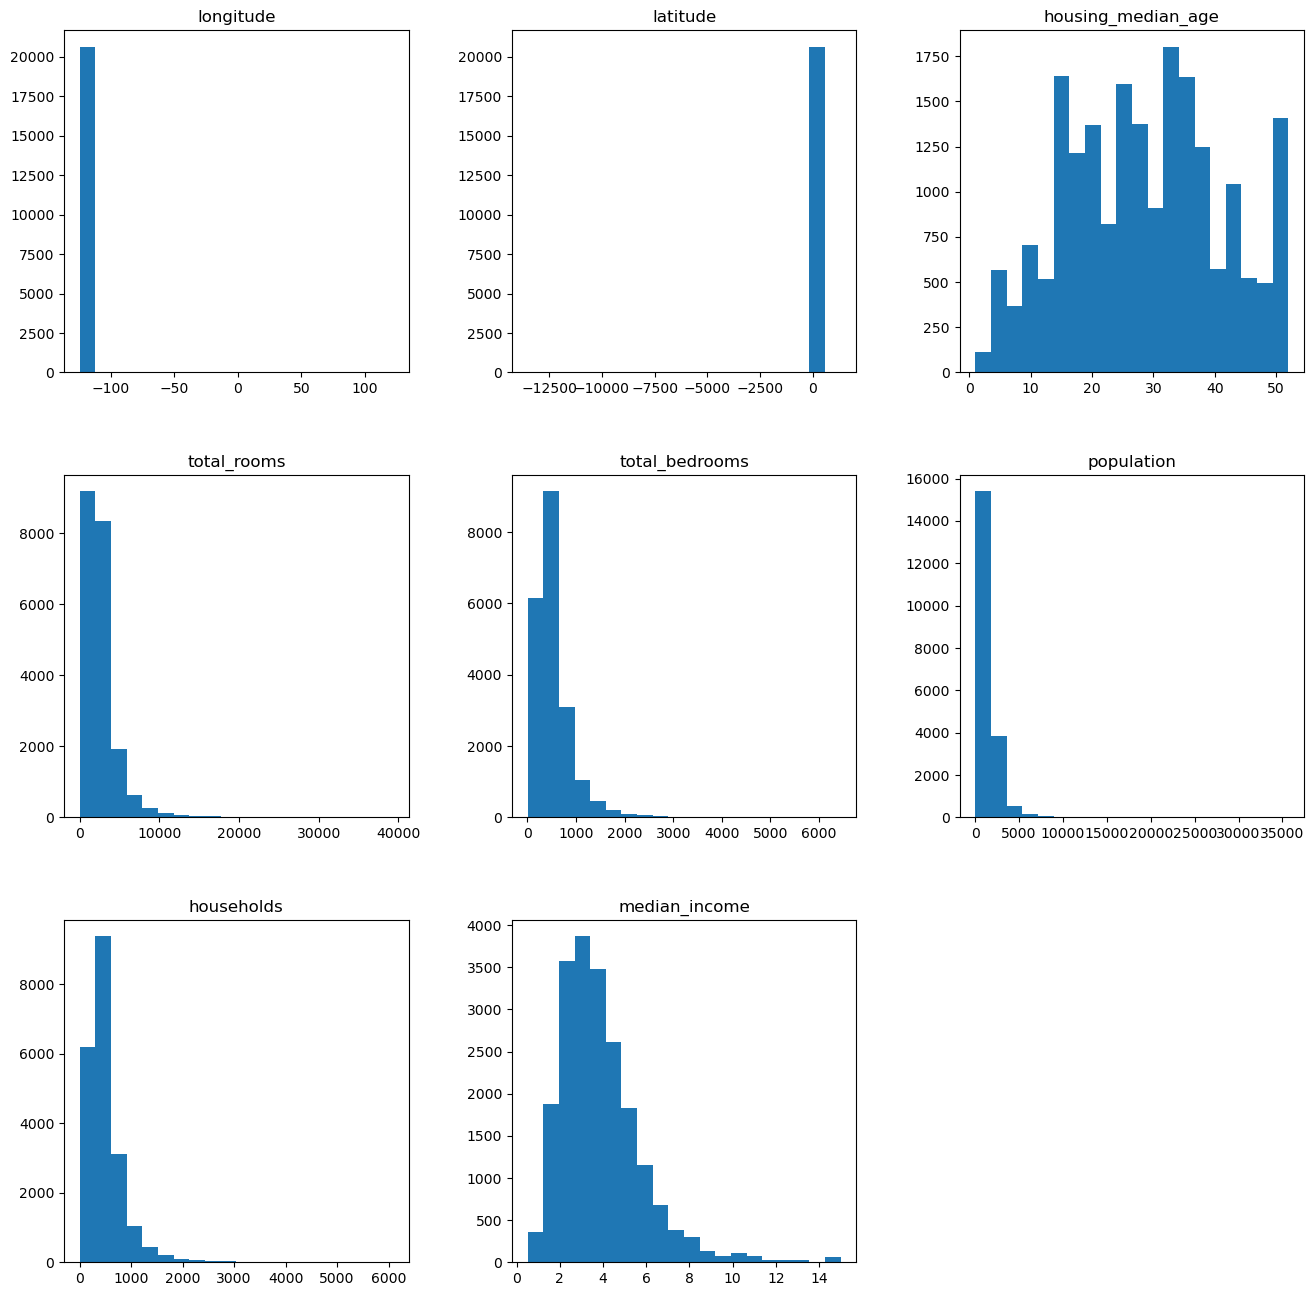

In [27]:
df_num_features.hist(figsize=(16, 16), bins=20, grid=False)

plt.savefig('../charts/Num features hist.png', dpi=150, bbox_inches='tight')

В longitude(долгота) имеются выбросы, ибо дома находятся в северном полушарии в Калифорнии. В latitude(широта) тоже имеются выбросы (широта от -90 до 90) Выбросы в total_rooms - слишком много комнат в некоторых домах(40000) Выбросы в total_bedrooms - слишком много спален (6000) Выбросы в population - в среднем население 7-8 тыс, в некоторых домиках 35000 В households выбросы (6000)

Посмотрим на взаимное распределение данных

Гипотеза: если люди могут позволить себе очень много спален в доме, то они очень обеспеченные

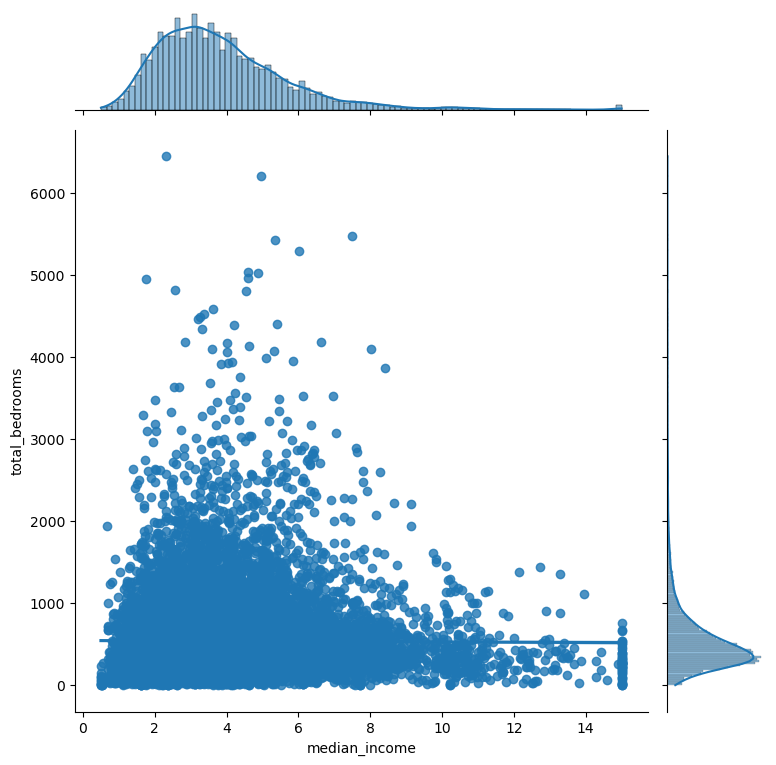

In [28]:
grid = sns.jointplot(data=df, x='median_income', y='total_bedrooms', kind='reg')
grid.fig.set_size_inches(8,8)

plt.show()

Гипотеза неверна: много людей с низким заработком, у которых много спален

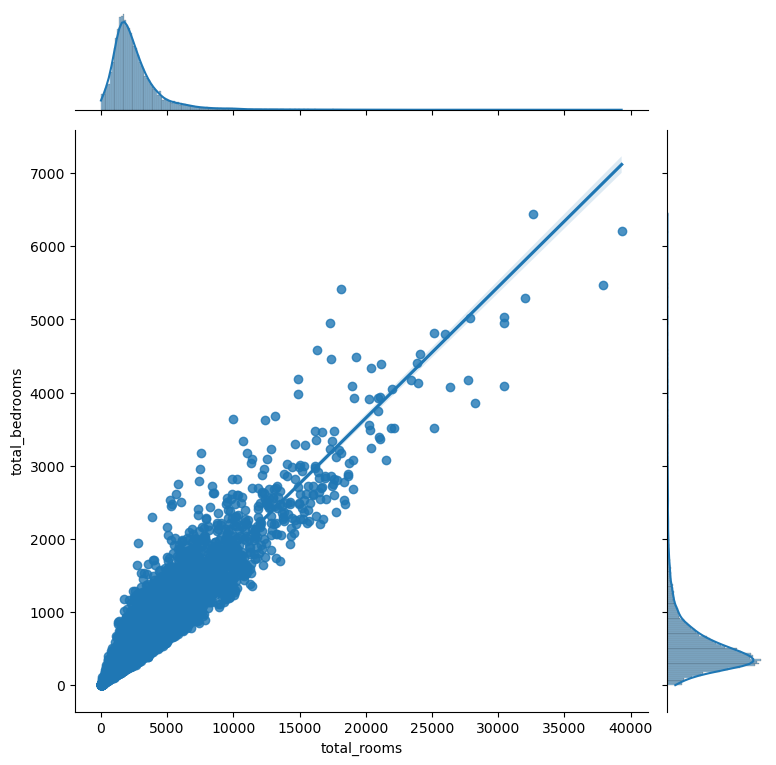

In [29]:
grid = sns.jointplot(data=df, x='total_rooms', y='total_bedrooms', kind='reg')
grid.fig.set_size_inches(8,8)

plt.savefig('../charts/total_rooms and total_bedrooms jointplot', dpi=150, bbox_inches='tight')

Идеальная линейная связь

Поиск выбросов с помощью box plot

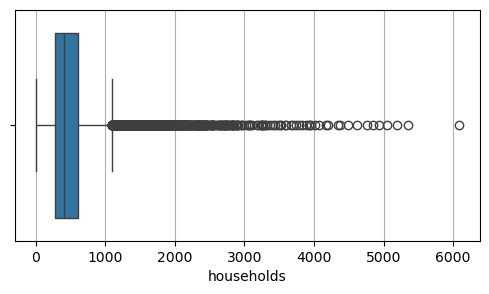

In [30]:
plt.figure(figsize=(6,3))
plt.grid()

sns.boxplot(data=df, x='households', whis=1.5)

plt.savefig('../charts/Box plot households.png', dpi=150, bbox_inches='tight')

Выкинем объекты у которых больше 1000 и заменим их на медиану

In [31]:
df.loc[df['households'] > 1000, 'households'] = df['households'].median()

<Axes: >

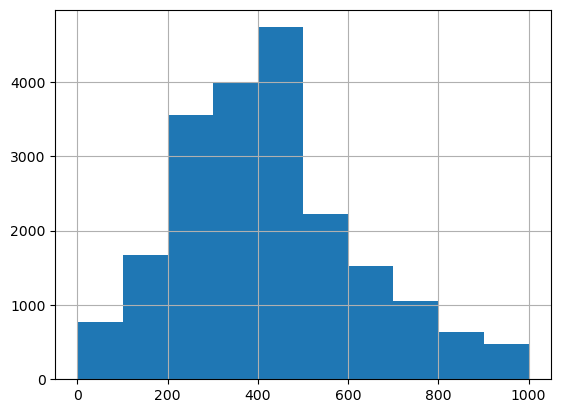

In [32]:
df['households'].hist()

2.3 Категориальные признаки

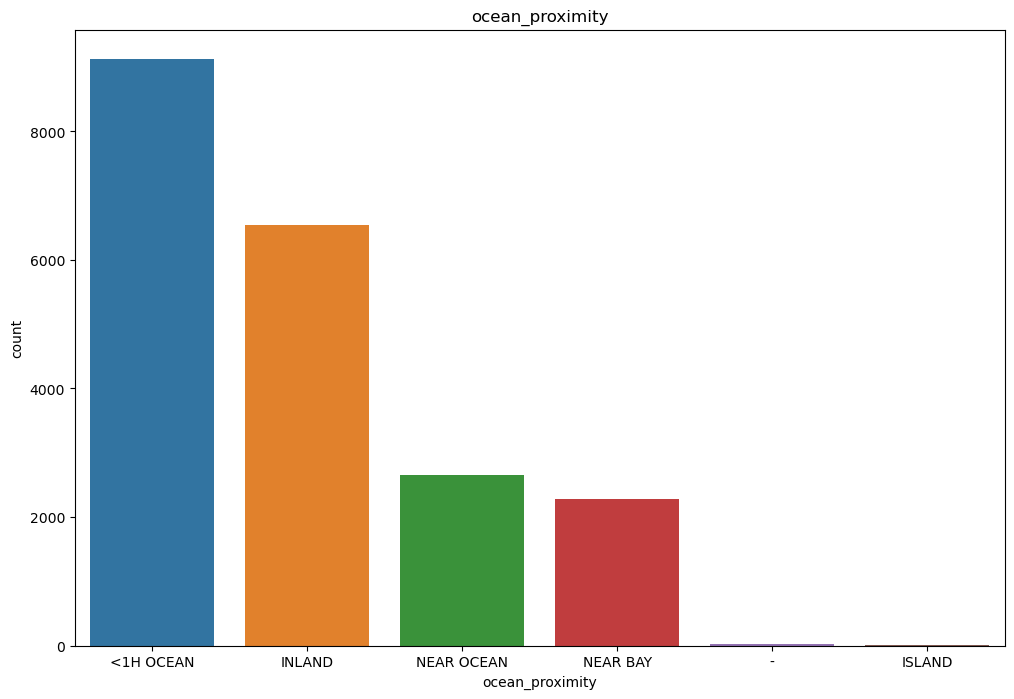

In [33]:
counts = df['ocean_proximity'].value_counts().reset_index()
counts.columns = ['ocean_proximity', 'count']

plt.figure(figsize=(12,8))
plt.title('ocean_proximity')
sns.barplot(data=counts, x='ocean_proximity', y='count', hue='ocean_proximity')

plt.savefig('../charts/Bar chart ocean_proximity.png', dpi=150, bbox_inches='tight')

plt.show()

2.3 Матрица корреляций

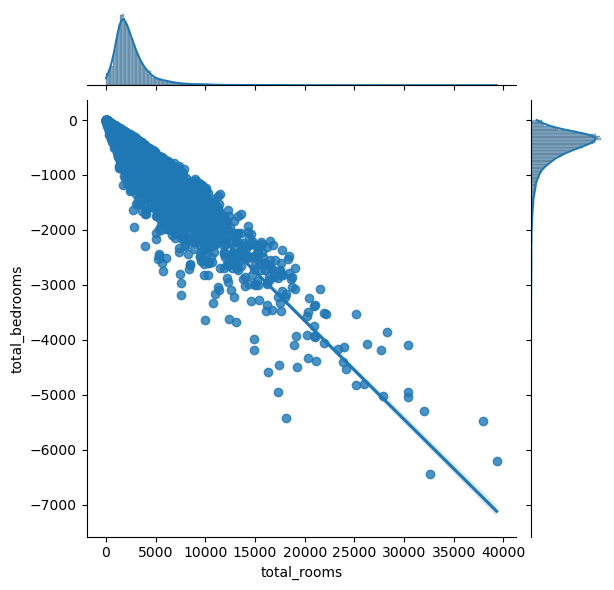

In [34]:
grid = sns.jointplot(data=df, x='total_rooms', y=df['total_bedrooms']*(-1), kind='reg')
#plt.grid()

plt.savefig('../charts/Jointplot total_rooms of total_bedrooms.png', dpi=150, bbox_inches='tight')
plt.show()

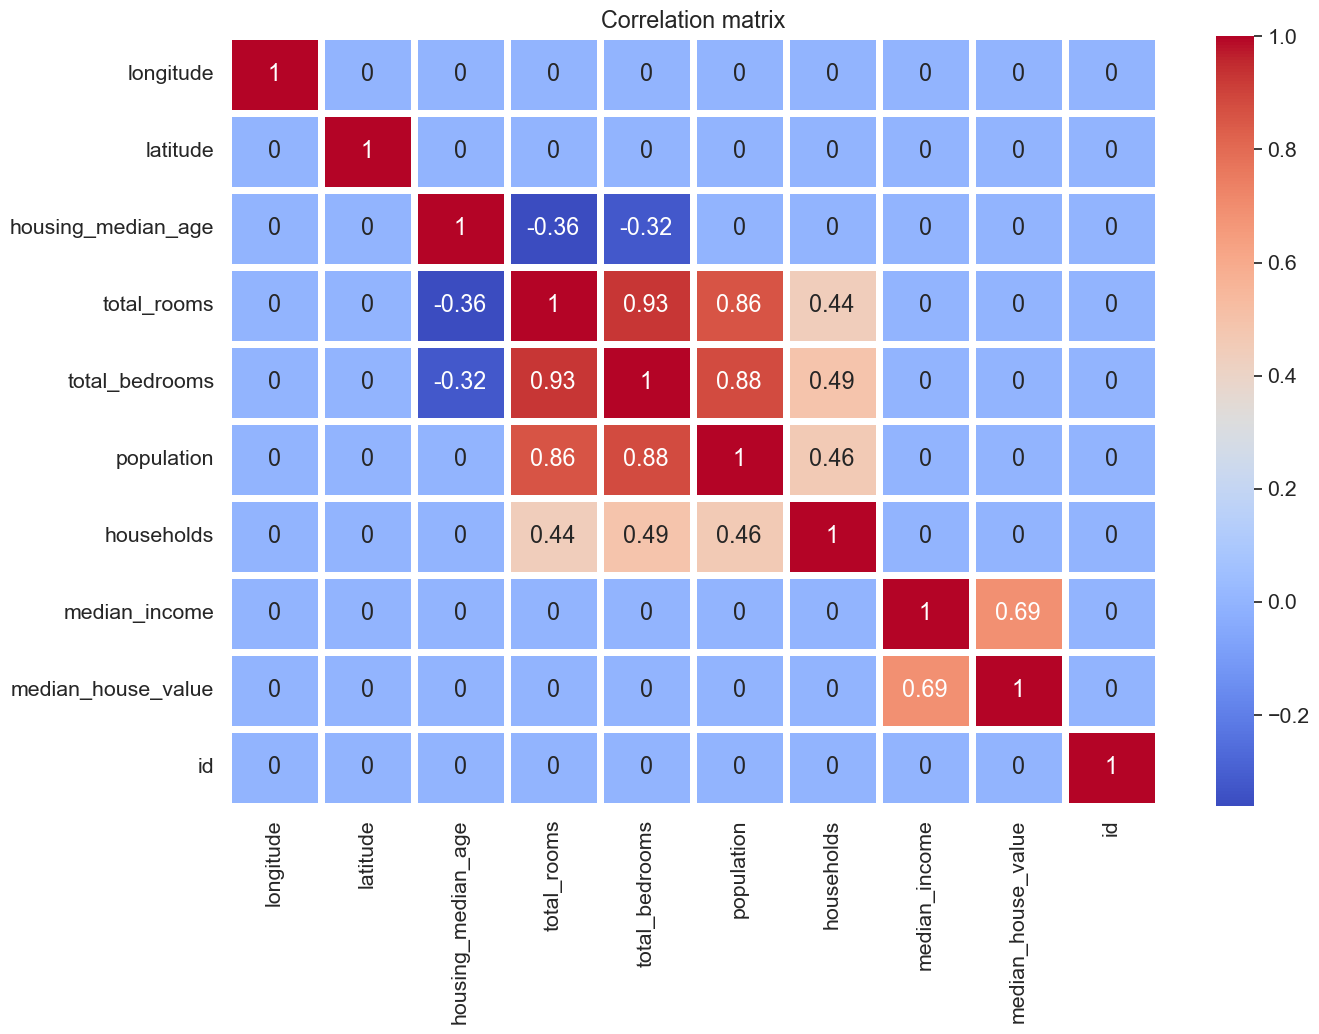

In [35]:
plt.figure(figsize=(15,10))

sns.set(font_scale=1.4)

corr_matrix = df.corr(numeric_only=True)
corr_martix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.3] = 0

sns.heatmap(data=corr_matrix, annot=True, linewidths=5, cmap='coolwarm')

plt.title('Correlation matrix')
plt.savefig('../charts/Correlation matrix.png', dpi=150, bbox_inches='tight')
plt.show()

3. Анализ зависимости таргета от фичей

3.1 Количественные признаки

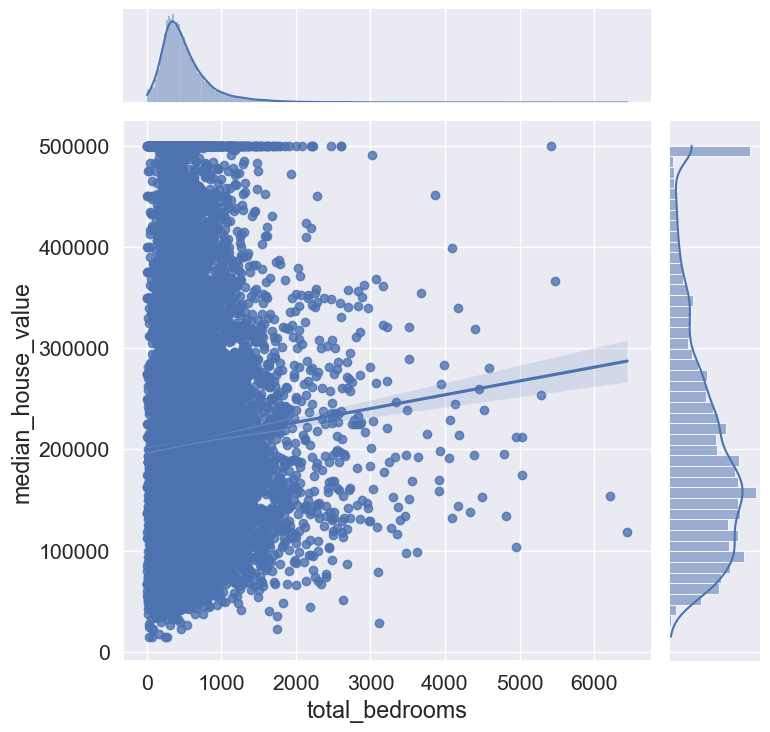

In [36]:
grid = sns.jointplot(data=df, x='total_bedrooms', y='median_house_value', kind='reg')
grid.fig.set_size_inches(8, 8)

plt.savefig('../charts/median_house_value by total_bedrooms.png', dpi=150, bbox_inches='tight')

Очень небольшая линейная связь

Долгота(longitude) для Калифорнии должна быть в отрицательных значениях, поэтому все положительные объекты в долготе меняем на медиану

In [37]:
df.loc[df['longitude'] >= 0, 'longitude'] = df['longitude'].median()

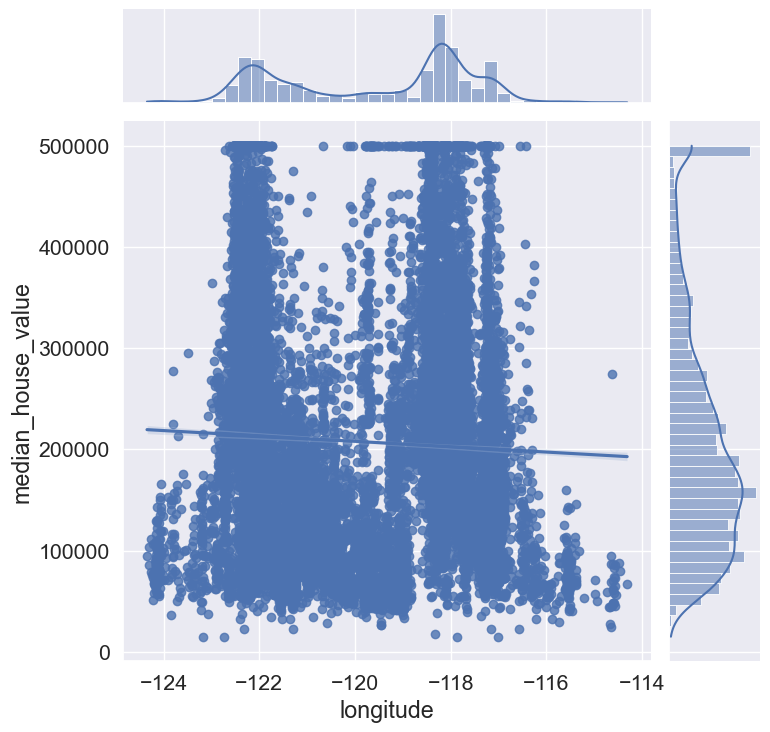

In [38]:
grid = sns.jointplot(data=df, x='longitude', y='median_house_value', kind='reg')
grid.fig.set_size_inches(8, 8)

plt.savefig('../charts/median_house_value by longitude.png', dpi=150, bbox_inches='tight')

Сделаем разбивку по -120 долготе и будем анализировать все города в отдельности

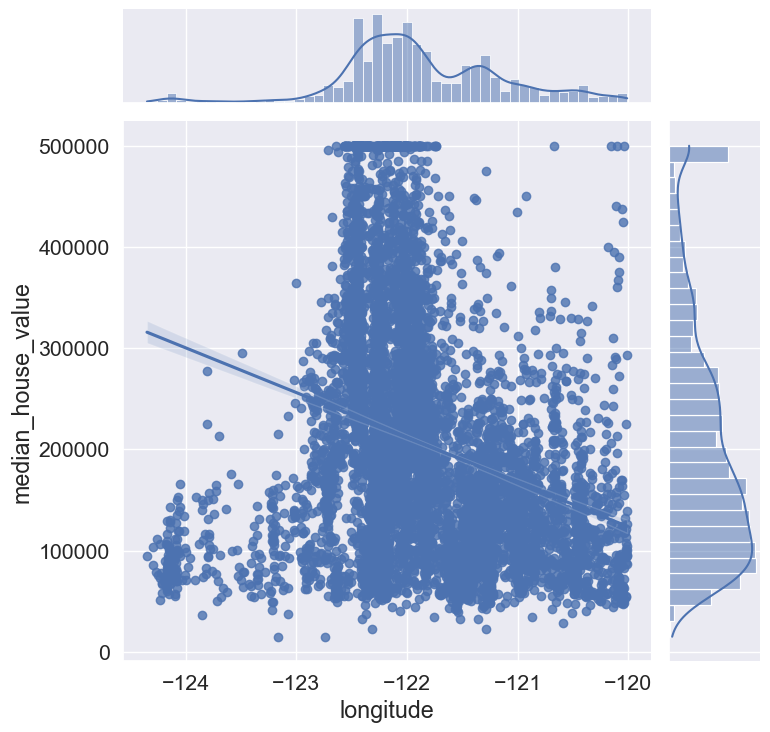

In [39]:
df_cut = df[df['longitude'] < -120]

grid = sns.jointplot(data=df_cut, x='longitude', y='median_house_value', kind='reg')
grid.fig.set_size_inches(8,8)

plt.savefig('../charts/median_house_value by longitude low -120.png', dpi=150, bbox_inches='tight')

plt.show()

Небольшая связь: чем дальше дом от океана, тем он дешевле

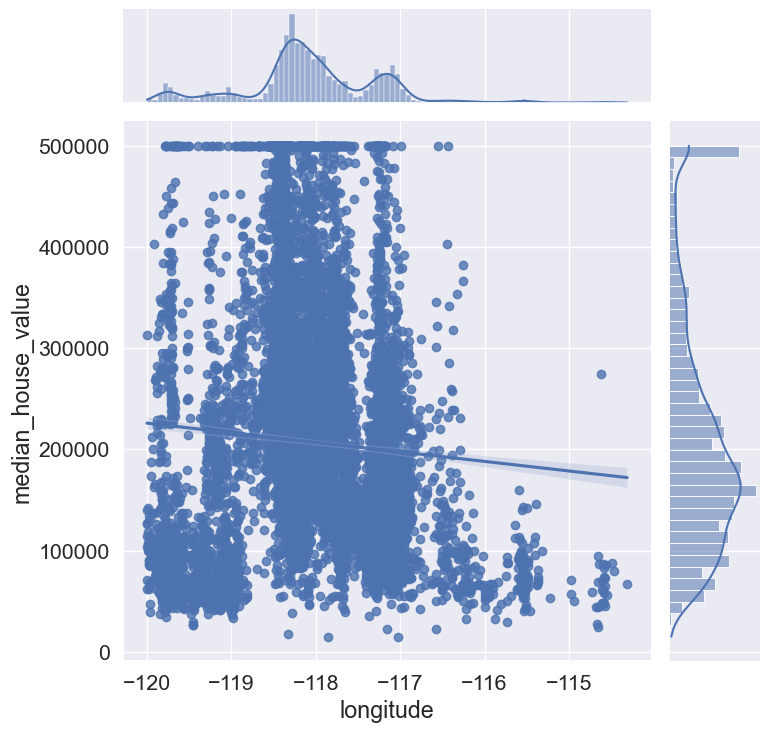

In [40]:
df_cut = df[df['longitude'] >= -120]

grid = sns.jointplot(data=df_cut, x='longitude', y='median_house_value', kind='reg')
grid.fig.set_size_inches(8,8)

plt.savefig('../charts/median_house_value by longitude higher -120.png', dpi=150, bbox_inches='tight')

plt.show()

Готовим данные для графиков

In [41]:
df['higher 150000'] = df['median_house_value'] > 150000
data = df[['higher 150000', 'median_income', 'population', 'total_rooms']]
data.head()

,higher 150000,median_income,population,total_rooms
0,True,8.3252,322.0,880.0
1,True,8.3014,2401.0,7099.0
2,True,7.2574,496.0,1467.0
3,True,5.6431,558.0,1274.0
4,True,3.8462,565.0,1627.0


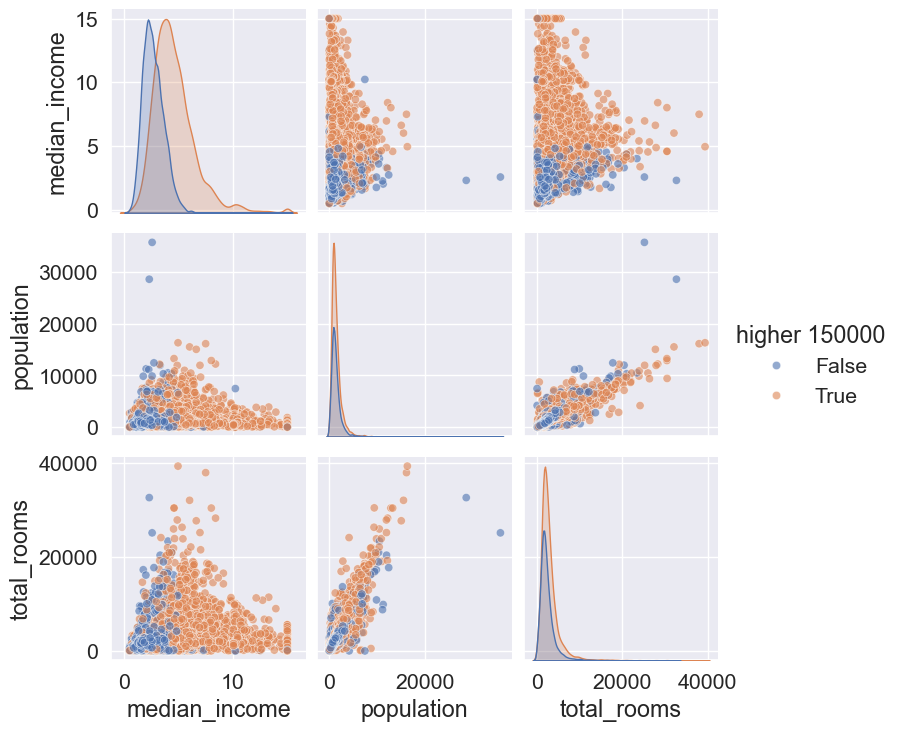

In [42]:
sns.pairplot(data=data, hue='higher 150000', plot_kws={'alpha': 0.6})
plt.savefig('../charts/All pairs.png', dpi=150, bbox_inches='tight')

Если очень большой заработок, то чаще всего дом будет стоить больше 150000

3.2 Категориальные/бинарные признаки

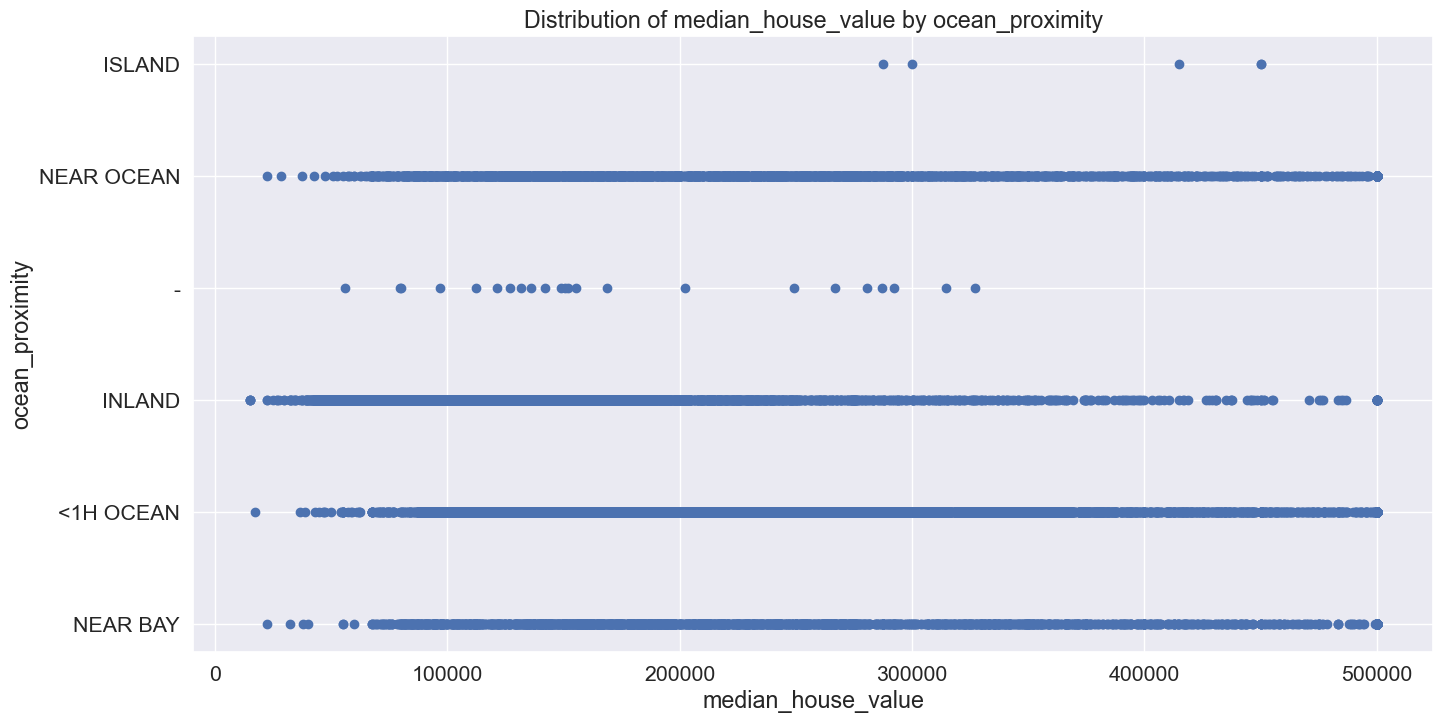

In [43]:
plt.figure(figsize=(16,8))

plt.scatter(df['median_house_value'], df['ocean_proximity'])
plt.xlabel('median_house_value')
plt.ylabel('ocean_proximity')
plt.title('Distribution of median_house_value by ocean_proximity')

plt.show()

Ничего кроме нескольких домиков на островах различить не сможем

Проанализируем с помощью ящиков с усами

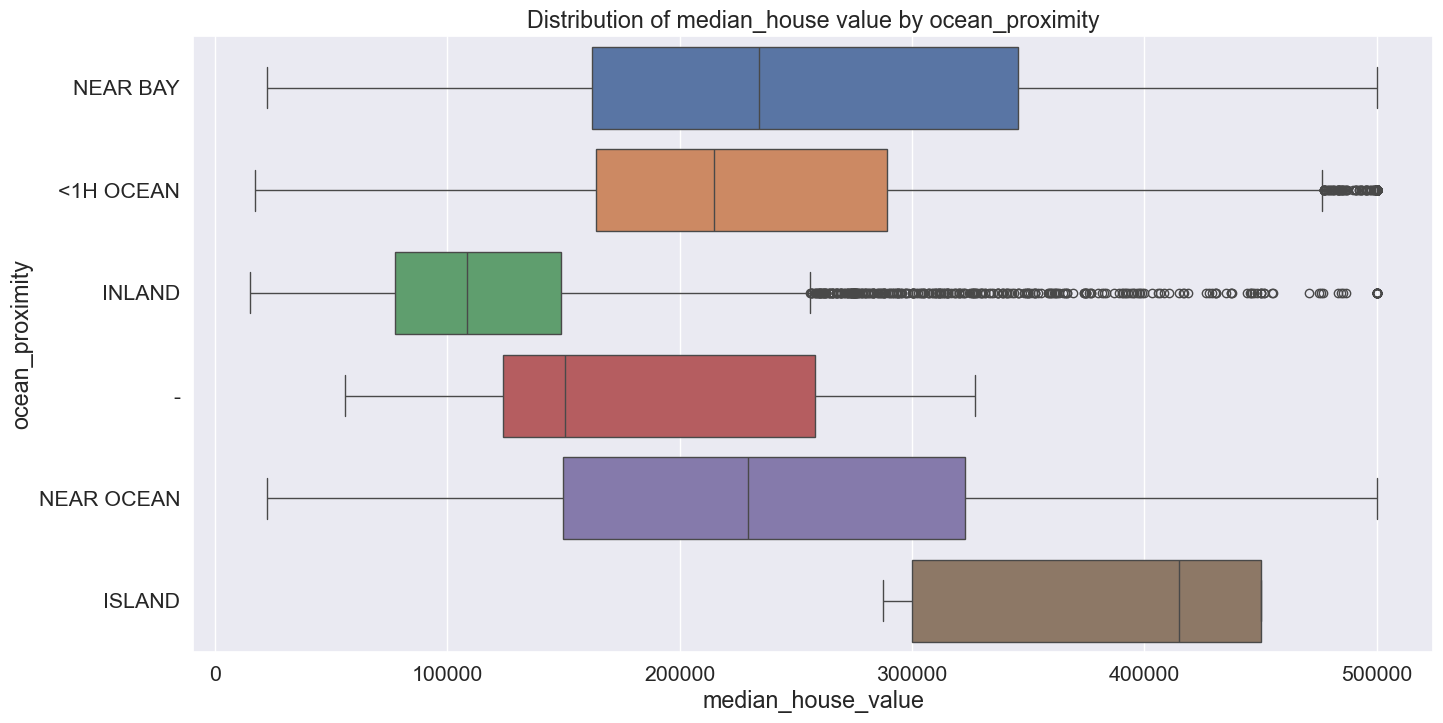

In [44]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df, x='median_house_value', y='ocean_proximity', whis=1.5, hue='ocean_proximity')

plt.xlabel('median_house_value')
plt.ylabel('ocean_proximity')
plt.title('Distribution of median_house value by ocean_proximity')
plt.savefig('../charts/Distribution of median_house_value by ocean_proximity boxplot.png', dpi=150, bbox_inches='tight')

plt.show()

Материковые домики самые дешёвые. Островные самые дорогие. Дома около океана, в часе езды, в бухте, стоят одинаково

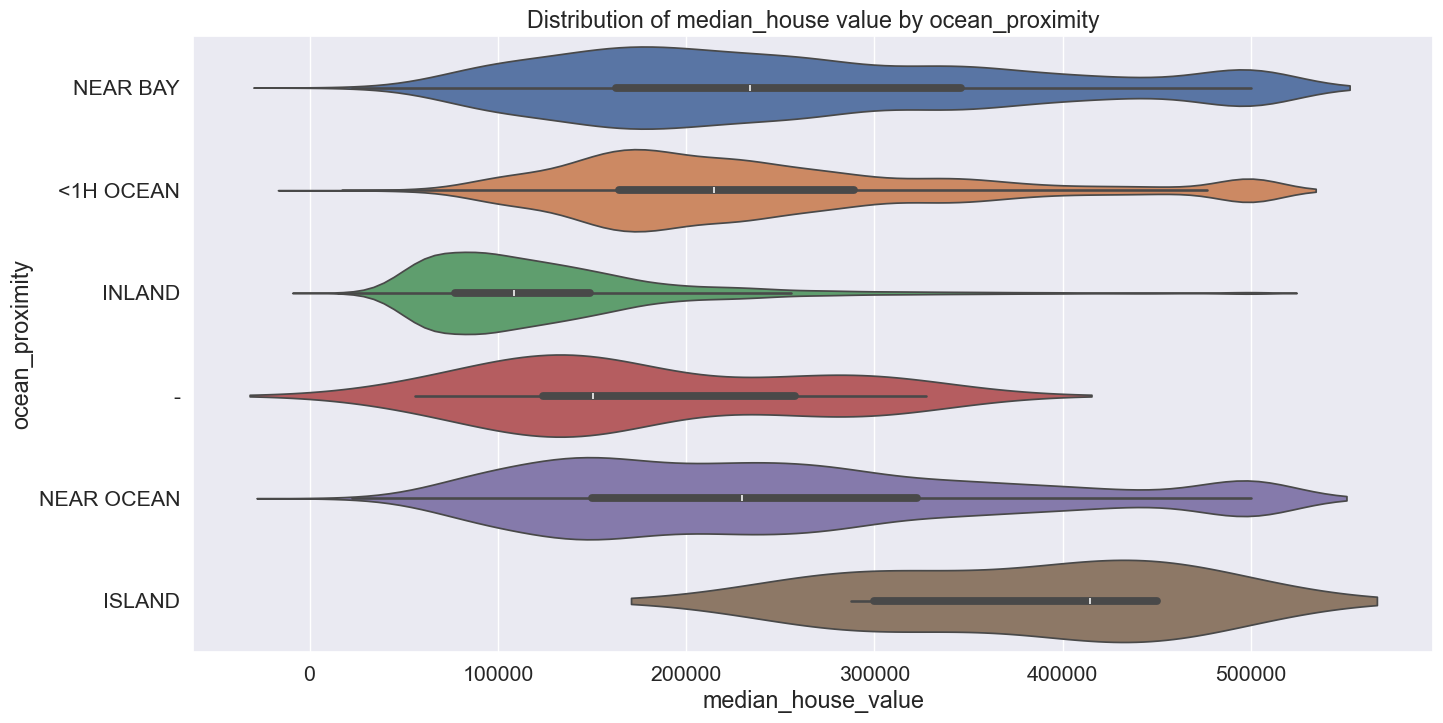

In [45]:
plt.figure(figsize=(16, 8))

sns.violinplot(data=df, x='median_house_value', y='ocean_proximity', hue='ocean_proximity')

plt.xlabel('median_house_value')
plt.ylabel('ocean_proximity')
plt.title('Distribution of median_house value by ocean_proximity')
plt.savefig('../charts/Distribution of median_house_value by ocean_proximity violin.png', dpi=150, bbox_inches='tight')

plt.show()